In [1]:
import pandas as pd  # Data manipulation
import numpy as np   # Numerical operations
import os            # File path operations
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding libraries (not used here but useful for categorical features)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Scaling library (not used here but useful for normalization)
from sklearn.preprocessing import StandardScaler

# Data splitting and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
from hyperopt import fmin, tpe, hp, Trials, SparkTrials, STATUS_OK

In [2]:
current_dir = os.getcwd()
file_path = os.path.join(current_dir, "..", "data", "final_data", "model_input.csv")
file_path = os.path.abspath(file_path)

df_input = pd.read_csv(file_path)
print(df_input.shape)  # Print shape to confirm data loaded
print('')
df_input.head()        # Show first few rows

(5000, 33)



,Unnamed: 0,NPI_ID,HCP_ID,TARGET,Age,Number_of_Rx,Rx_last_1_Month,Rx_last_3_Month,Rx_last_6_Month,Rx_last_12_Month,...,Promotional_medscape_last_3_month,Promotional_medscape_last_6_month,F2F_visit,F2F_visit_last_1_month,F2F_visit_last_3_month,VRC_visit_last_3_month,VRC_visit_last_6_month,VRC_visit_last_12_month,HCO_Affiliation_Type_Contract,HCO_Affiliation_Type_Referral
0,0,9846255,HCP_1,0,64,290,400,492,770,1373,...,18,30,1,2,3,5,9,16,0,1
1,1,5217093,HCP_2,0,64,645,923,1628,2210,2449,...,14,21,2,4,6,3,6,11,0,0
2,2,2659257,HCP_3,0,56,879,1062,1918,3505,6169,...,20,29,1,2,3,6,8,11,0,0
3,3,9851763,HCP_4,0,74,392,704,1036,1078,1184,...,16,21,1,2,4,4,6,7,0,0
4,4,6650853,HCP_5,0,46,1043,1228,1305,1339,2483,...,15,30,1,2,3,6,9,16,1,0


In [3]:
# Define features and target
X = df_input.drop("TARGET", axis=1)
y = df_input["TARGET"]

# First, split off the test set (10%)
X_train_pre, X_test, y_train_pre, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Then, split the remaining data into train (70%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_train_pre, y_train_pre, test_size=0.2, random_state=42, stratify=y_train_pre)

# Print shapes and class distributions for each split
print('shape of train data: ')
print(X_train.shape)
print('')
print(y_train.shape)
print('')
print("Distribution of target variable: ", y_train.value_counts(normalize=True))
print('')
print('shape of validation data: ')
print(X_val.shape)
print('')
print(y_val.shape)
print('')
print("Distribution of target variable: ", y_val.value_counts(normalize=True))
print('')
print('shape of test data: ')
print(X_test.shape)
print('')
print(y_test.shape)
print('')
print("Distribution of target variable: ", y_test.value_counts(normalize=True))
print('')

shape of train data: 
(3600, 32)

(3600,)

Distribution of target variable:  0    0.743889
1    0.256111
Name: TARGET, dtype: float64

shape of validation data: 
(900, 32)

(900,)

Distribution of target variable:  0    0.743333
1    0.256667
Name: TARGET, dtype: float64

shape of test data: 
(500, 32)

(500,)

Distribution of target variable:  0    0.744
1    0.256
Name: TARGET, dtype: float64



In [17]:
#id col not to be considered while training
drop_id_col_list = ['NPI_ID', 'HCP_ID','Unnamed: 0']

In [9]:
import mlflow
import mlflow.sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from pathlib import Path

# --- Set tracking info ---
base_dir = Path("..").resolve()  # adjust if notebook is elsewhere
mlflow_db_path = base_dir / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{mlflow_db_path}")
mlflow.set_experiment("Physician Conversion Classifier Experiment Tracker")


2025/05/19 22:13:26 INFO mlflow.tracking.fluent: Experiment with name 'Physician Conversion Classifier Experiment Tracker' does not exist. Creating a new experiment.


<Experiment: artifact_location=('/Users/harshitsundriyal/Desktop/Professional-learning/ML_Eng/AI-ML '
 'Turks/Physician_Conversion_Model/notebooks/mlruns/2'), creation_time=1747673006398, experiment_id='2', last_update_time=1747673006398, lifecycle_stage='active', name='Physician Conversion Classifier Experiment Tracker', tags={}>

In [10]:

# --- Decision Tree parameters ---
dt_params = {
    "max_depth": 11,
    "max_features": 0.9270664720560604,
    "min_samples_leaf": 4,
    "min_samples_split": 2  # MLflow needs > 0, 0 would raise ValueError
}
# --- Train and Evaluate ---
with mlflow.start_run(run_name="decision_tree_model"):
    # Prepare training data
    X_train_filtered = X_train.drop(drop_id_col_list, axis=1, errors="ignore")
    X_val_filtered = X_val.drop(drop_id_col_list, axis=1, errors="ignore")

    # Train
    clf = DecisionTreeClassifier(**dt_params)
    clf.fit(X_train_filtered, y_train)

    # Predict and evaluate
    preds = clf.predict(X_val_filtered)
    probs = clf.predict_proba(X_val_filtered)[:, 1]

    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)

    # Log to MLflow
    mlflow.log_params(dt_params)
    mlflow.log_metrics({"accuracy": acc, "roc_auc": roc})
    mlflow.sklearn.log_model(clf, "model")

2025/05/19 22:13:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/05/19 22:13:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [19]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)

# --- Best Hyperparameters for XGB ---
best_param = {
    'colsample_bytree': 0.8011137517906433,
    'gamma': 0.0003315092691686855,
    'max_depth': 7,
    'reg_alpha': 0.20064996416845873,
    'subsample': 0.19265865309365698,
    'use_label_encoder': False,  # Required to suppress warning
    'eval_metric': 'logloss'
}

# --- Train and Evaluate ---
with mlflow.start_run(run_name="xgboost_model"):
    # Prepare data
    X_train_filtered = X_train.drop(drop_id_col_list, axis=1, errors="ignore")
    X_val_filtered = X_val.drop(drop_id_col_list, axis=1, errors="ignore")

    # Sanitize column names to be safe for any ML library
    X_train_filtered.columns = X_train_filtered.columns.str.replace(r'[^\w]', '_', regex=True)
    X_val_filtered.columns = X_val_filtered.columns.str.replace(r'[^\w]', '_', regex=True)

    # Train model
    model = xgb.XGBClassifier(**best_param)
    model.fit(X_train_filtered, y_train)

    # Predict
    preds = model.predict(X_val_filtered)
    probs = model.predict_proba(X_val_filtered)[:, 1]

    # Evaluate metrics
    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    f1 = f1_score(y_val, preds)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    # Log params and metrics
    mlflow.log_params(best_param)
    mlflow.log_metrics({
        "accuracy": acc,
        "roc_auc": roc,
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

    # Log the model
    mlflow.xgboost.log_model(model, "model")

2025/05/19 22:44:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/05/19 22:44:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[LightGBM] [Info] Number of positive: 922, number of negative: 2678
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3782
[LightGBM] [Info] Number of data points in the train set: 3600, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.256111 -> initscore=-1.066280
[LightGBM] [Info] Start training from score -1.066280


2025/05/19 22:35:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/05/19 22:35:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


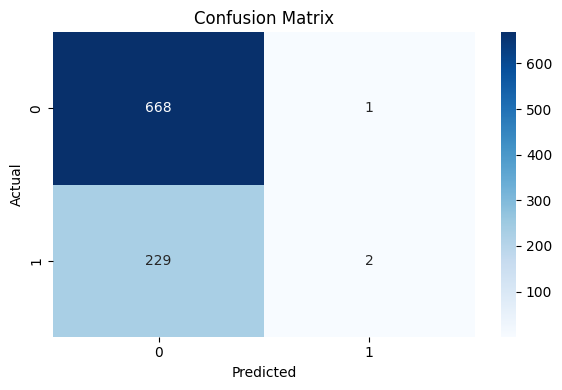

In [18]:
import mlflow
import mlflow.lightgbm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# --- Best Hyperparameters for LGBM ---
best_params = {
    "colsample_bytree": 0.6993766257882146,
    "learning_rate": 0.16544950335990477,
    "max_depth": 6,
    "min_child_weight": 1,
    "num_leaves": 3,
    "reg_alpha": 0.0031158940787242963,
    "reg_lambda": 0.011363424249951272,
    "objective": "binary",
    "metric": "binary_logloss"
}

# --- Train and Evaluate ---
with mlflow.start_run(run_name="lightgbm_model"):
    # Prepare data
    X_train_filtered = X_train.drop(drop_id_col_list, axis=1, errors="ignore")
    X_val_filtered = X_val.drop(drop_id_col_list, axis=1, errors="ignore")

    # Train model
    model = lgb.LGBMClassifier(
        n_jobs=-1,
        **best_params
    )
    model.fit(X_train_filtered, y_train)

    # Predict
    probs = model.predict_proba(X_val_filtered)[:, 1]
    preds = model.predict(X_val_filtered)

    # Evaluate
    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    cm = confusion_matrix(y_val, preds)

    # Log metrics
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        "accuracy": acc,
        "roc_auc": roc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    # Confusion matrix plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Classification report
    report = classification_report(y_val, preds)
    with open("classification_report.txt", "w") as f:
        f.write(report)
    mlflow.log_artifact("classification_report.txt")

    # Log model
    mlflow.lightgbm.log_model(model, "model")